# Case Study of Switch Design and Analysis 

## Time Delay Impact on DRL Agent (RQ1)

In [1]:
# functions for information extraction
import pandas as pd
import ast
import re

# extract configuration information
def extract_config(lines):
    switch_config_target = "Switch configurations:"
    pctrl_only_target = "'--pctrl-only'"
    config_data = {}
    found_switch_config = False
    for _, line in enumerate(lines):
        if pctrl_only_target in line:
            pctrl_only_str = line.strip().replace("--", "").split(':')[1].strip()
            pctrl_only = ast.literal_eval(pctrl_only_str)
            config_data['pctrl_only'] = pctrl_only[0]
        elif switch_config_target in line:
            found_switch_config = True
        elif found_switch_config:
            # Safely evaluate the config string to a Python list containing a dictionary
            item_list = ast.literal_eval(line)
            if isinstance(item_list, list) and len(item_list) > 0 and isinstance(item_list[0], dict):
                record = item_list[0]     
                config_data['ctrl_id'] = record.get('ctrl_id') if not config_data['pctrl_only'] else None
                thresh = record.get('thresh', {}) 
                config_data['time_thd'] = thresh.get('time_delay') if not config_data['pctrl_only'] else None
                config_data['cross_lane_hw'] = thresh.get('cross_lane_headway') if not config_data['pctrl_only'] else None  
            found_switch_config = False  
    return config_data

# extract delay time
def extract_delay_time(lines):
    target = '--deterministic-delay'
    target2 = '--avg-delay'
    for _, line in enumerate(lines):
        if target in line or target2 in line:
            target_str = line.split(':')[1].replace("'", "").replace(",", "").strip()
            if target_str != "None":
                try: 
                    target_val = float(target_str)
                    return target_val
                except ValueError:
                    print(f"Warning: Could not convert '{target_str}' to floats")
     

# extract switch probabilities
def extract_switch_probs(lines):
    _dict = {}
    for line in lines:
        if line.startswith("[probabilities]"):
            # Use regular expression to find all numbers in the line
            numbers_str = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers_str) >= 2:
                try:
                    #_dict["prob_pri_ctrl"] = float(numbers_str[0])
                    _dict["Sec Ctrl Et (p)"] = 1 - float(numbers_str[0])
                except ValueError:
                    print(f"Warning: Could not convert first two elements to numbers in line: {line.strip()}")
    return _dict

# extract exit probabilities 
def extract_exit_probs(lines):
    _dict = {}
    for line in lines:
        if line.startswith("[counts]"):
            # Use regular expression to find all numbers in the line
            numbers_str = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers_str) >= 3:
                try:
                    num1 = int(numbers_str[1])
                    num2 = int(numbers_str[2])
                    if num1 * num2 < 0 or num1 + num2 <= 0:
                        raise ValueError("Both counts must be non-negative and at least one count must be positive")
                    p = num1 / float(num1 + num2)
                    _dict["Sec Ctrl Ex (p)"] = p
                    #_dict["prob_stay_in_sec_ctrl"] = 1 - p
                except ValueError:
                    print(f"Warning: Could not convert first three elements to numbers in line: {line.strip()}")
    return _dict

def extract_metrics_data_to_df(lines):
    extracted_data = [] 
    for line in lines:
        if line.startswith("[data]"):
                data_part = line[len("[data]"):].strip()
                pairs = data_part.split(', ')
                data_dict = {}
                for pair in pairs:
                    if ':' in pair:
                        key, value = pair.split(': ', 1)
                        data_dict[key.strip()] = value.strip()
                extracted_data.append(data_dict)
    if extracted_data:
        df = pd.DataFrame(extracted_data)
        df['headway'] = df['headway'].astype('float')
        # df['cross_lane_headway'] = df['cross_lane_headway'].astype('float')
        df['ttc'] = df['ttc'].astype('float')
        def bool_str_to_num(x):
            if x=='True':
                return 1  
            else:
                return 0
        df['on lane'] = df['on lane'].apply(bool_str_to_num)
        df = df.drop(['cross_lane_headway'], axis=1)
        return df
    else:
        raise ValueError("Empty data")  # Return an empty DataFrame

In [2]:
import os
# directory of input data for delay impact experiment 1
current_folder = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))

#folder of determinsitic delay impact data 
input_dir_dd = parent_folder + "/out/highway_env_continuous_actions/experiment/run1"

#folder of randomised delay impact data 
input_dir_rd = parent_folder + "/out/highway_env_continuous_actions/experiment/run1r"

In [3]:
def generate_time_delay_impacts(input_dir):
    list_of_dfs = []
    for root, _, files in os.walk(input_dir):
            for file in files:
                if file.endswith("log.txt"):
                    file_path = os.path.join(root, file)
                    try:
                        with open(file_path, 'r') as f:
                            lines = f.readlines()   
                            dt = extract_delay_time(lines)
                            dc = extract_config(lines)
                            df = extract_metrics_data_to_df(lines)
                            list_of_dfs.append((dt, dc, df))
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
    import pandas as pd
    list_of_dfs.sort(key=lambda item: item[0])
    
    exp_res_list = [];
    for dt, dc, df in list_of_dfs:
        headway_median = df["headway"].median()
        ttc_qt = df["ttc"].quantile(0.1)
        lane_dep_mean = 1 - df["on lane"].mean()
        exp_res_list.append([dt, dc["ctrl_id"], dc["time_thd"], headway_median, ttc_qt, lane_dep_mean])
    column_names = ["Delay", "ctrl_id", "time_thd", "HW (P50)", "TTC (P10)", "LD (prob)"]
    exp_res = pd.DataFrame(exp_res_list, columns=column_names)
    exp_res = exp_res[["Delay", "ctrl_id", "time_thd", "LD (prob)",'TTC (P10)', 'HW (P50)']]
    return exp_res
print("--deterministic delays--")
df_det_delay_impacts = generate_time_delay_impacts(input_dir_dd)
print(df_det_delay_impacts.drop(["ctrl_id", "time_thd"], axis=1).round(4).to_string())
print("--randomised delays--")
df_ram_delay_impacts = generate_time_delay_impacts(input_dir_rd)
print(df_ram_delay_impacts.drop(["ctrl_id", "time_thd"], axis=1).round(4).to_string())

--deterministic delays--
    Delay  LD (prob)  TTC (P10)  HW (P50)
0    0.00     0.0001    28.0064    4.8403
1    0.05     0.0000    27.8275    4.7022
2    0.10     0.0001    24.9783    4.0851
3    0.15     0.0328    20.6544    4.2097
4    0.20     0.2317    16.8771    4.6250
5    0.25     0.2443    16.5498    4.6607
6    0.30     0.5406    11.7091    4.7424
7    0.35     0.5924     9.5142    4.6305
8    0.40     0.6324     8.7159    4.7036
9    0.45     0.6378     8.8419    4.7278
10   0.50     0.6308     9.2667    5.0252
--randomised delays--
   Delay  LD (prob)  TTC (P10)  HW (P50)
0   0.05     0.0003    18.8983    4.3366
1   0.10     0.0063    17.5975    3.8275
2   0.15     0.0354    15.4452    3.7491
3   0.20     0.1152    14.4638    3.9710
4   0.25     0.1923    13.3526    4.1480
5   0.30     0.2849    12.7368    4.2904
6   0.35     0.3526    12.3128    4.5370
7   0.40     0.4057    11.6652    4.5911
8   0.45     0.4375    11.9127    4.6872
9   0.50     0.4655    12.1273    4.803

In [4]:
"""
import matplotlib.pyplot as plt
exp1_res = generate_time_delay_impacts(input_dir_1)

# Create a figure and a set of subplots
# 3 rows, 1 column, sharing the x-axis
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# Plot each column on a different subplot
axes[0].plot(exp1_res['delay_time'], exp1_res['on_lane_prob'], label='On-lane prob.', color='C0') # Use 'C0', 'C1', ... for default colors
axes[1].plot(exp1_res['delay_time'], exp1_res['ttc_10pt'], label='TTC 10 pencentile', color='C1')
axes[2].plot(exp1_res['delay_time'], exp1_res['headway_mean'], label='Avg Headway', color='C2')

# Add titles and labels
axes[0].set_title('On-Lane Probabiilty, TTC and Headway vs. delay') # Main title or set suptitle on fig
axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[2].set_xlabel('Delay time') # Only the bottom subplot needs the x-label

# Add legends to each subplot
axes[0].legend()
axes[1].legend()
axes[2].legend()

# Optional: Add grid
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)

# Improve layout
plt.tight_layout()
# Adjust layout to prevent the suptitle from overlapping the top plot
#fig.suptitle('Data from Columns b, c, and d vs. a (Separate Scales)', y=1.02)

# Show the plot
plt.show()
"""

"\nimport matplotlib.pyplot as plt\nexp1_res = generate_time_delay_impacts(input_dir_1)\n\n# Create a figure and a set of subplots\n# 3 rows, 1 column, sharing the x-axis\nfig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))\n\n# Plot each column on a different subplot\naxes[0].plot(exp1_res['delay_time'], exp1_res['on_lane_prob'], label='On-lane prob.', color='C0') # Use 'C0', 'C1', ... for default colors\naxes[1].plot(exp1_res['delay_time'], exp1_res['ttc_10pt'], label='TTC 10 pencentile', color='C1')\naxes[2].plot(exp1_res['delay_time'], exp1_res['headway_mean'], label='Avg Headway', color='C2')\n\n# Add titles and labels\naxes[0].set_title('On-Lane Probabiilty, TTC and Headway vs. delay') # Main title or set suptitle on fig\naxes[0].set_ylabel('')\naxes[1].set_ylabel('')\naxes[2].set_ylabel('')\naxes[2].set_xlabel('Delay time') # Only the bottom subplot needs the x-label\n\n# Add legends to each subplot\naxes[0].legend()\naxes[1].legend()\naxes[2].legend()\n\n# Optional: Ad

## Switch Design and Analysis (RQ2)

## Analysis Results of Switch with Randomised Delays Averaging 0.2 Second

In [5]:
import os
mopmc_home = os.getenv('MOPMC_HOME') 
storm_home = os.getenv('STORM_HOME') 
prism_home = os.getenv('PRISM_HOME') 
current_dir = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
switch_model = os.path.join(current_dir, 'switch_model.prism')
switch_metrics = os.path.join(current_dir, 'switch_metrics.props')
switch_metrics_dtmc = os.path.join(current_dir, 'switch_metrics_dtmc.props')
switch_metrics_no_multi = os.path.join(current_dir, 'switch_metrics_no_multi.props')
switch_metrics_mo = os.path.join(current_dir, 'switch_metrics_mo.props')
switch_metrics_mo2 = os.path.join(current_dir, 'switch_metrics_mo2.props')
switch_metrics_mo3 = os.path.join(current_dir, 'switch_metrics_mo3.props')
prism_executable = os.path.join(prism_home, 'bin', 'prism')
storm_executable = os.path.join(storm_home, 'build', 'bin', 'storm')
mopmc_executable = os.path.join(mopmc_home, 'build', 'mopmc')
mopmc_export_folder = os.path.join(parent_folder, 'out', 'mopmc_output')

In [6]:
import os
current_folder = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))

#folder of switch data
input_dir_switch_data = parent_folder + "/out/highway_env_continuous_actions/experiment/run2v2"
# input_dir_switch_data = parent_folder + "/out/highway_env_continuous_actions/experiment/run2"

In [7]:
df_ttc_hw_scores = df_ram_delay_impacts.copy().drop(['ctrl_id', 'time_thd'], axis=1)
df_ttc_hw_scores = df_ttc_hw_scores.set_index('Delay')
print(df_ttc_hw_scores)

       LD (prob)  TTC (P10)  HW (P50)
Delay                                
0.05    0.000325   18.89830   4.33660
0.10    0.006336   17.59750   3.82750
0.15    0.035395   15.44515   3.74910
0.20    0.115202   14.46380   3.97105
0.25    0.192270   13.35255   4.14795
0.30    0.284947   12.73685   4.29040
0.35    0.352614   12.31281   4.53700
0.40    0.405740   11.66524   4.59110
0.45    0.437500   11.91268   4.68715
0.50    0.465526   12.12725   4.80360


In [8]:
HEADWAY_SCORE_DEFAULT = df_ttc_hw_scores.loc[0.20, 'HW (P50)']
TTC_SCORE_DEFAULT = df_ttc_hw_scores.loc[0.20, 'TTC (P10)']
print(f"HEADWAY_SCORE_DEFAULT = {HEADWAY_SCORE_DEFAULT}")
print(f"TTC_SCORE_DEFAULT = {TTC_SCORE_DEFAULT}")

# extract metrics
"""
def generate_metrics_statistics(lines, headway_score=HEADWAY_SCORE_DEFAULT, ttc_score=HEADWAY_SCORE_DEFAULT):     
    df = extract_metrics_data_to_df(lines)
    n_rows = len(df)
    proportions = {}

    for val3 in [0, 1]:
        for op2 in ['<=', '>']:
            for op1 in ['<=', '>']:
                subset_name = f"HW({op1})&TTC({op2})&OL({val3})"

                condition1 = (df.iloc[:, 0] <= headway_score) if op1 == '<=' else (df.iloc[:, 0] > headway_score)
                condition2 = (df.iloc[:, 1] <= ttc_score) if op2 == '<=' else (df.iloc[:, 1] > ttc_score)
                condition3 = (df.iloc[:, 2] == val3)

                subset = df[condition1 & condition2 & condition3]
                proportions[subset_name] = len(subset) / n_rows if n_rows > 0 else 0.0

    return proportions
"""

def generate_metrics_statistics_v2(lines, headway_score=HEADWAY_SCORE_DEFAULT, ttc_score=TTC_SCORE_DEFAULT):     
    df = extract_metrics_data_to_df(lines)
    n_rows = len(df)
    proportions = {}
    cond_hw_leq_thd = (df.iloc[:, 0] <= headway_score)
    cond_ttc_leq_thd = (df.iloc[:, 1] <= ttc_score)
    
    proportions['HW (pr)'] = len(df[cond_hw_leq_thd]) / n_rows if n_rows > 0 else 0.0
    proportions['TTC (pr)'] = len(df[cond_ttc_leq_thd]) / n_rows if n_rows > 0 else 0.0
    #proportions['OL (p)'] = len(df[df.iloc[:, 2] == 1]) / n_rows if n_rows > 0 else 0.0
    proportions['LD (p)'] = len(df[df.iloc[:, 2] == 0]) / n_rows if n_rows > 0 else 0.0

    return proportions

HEADWAY_SCORE_DEFAULT = 3.97105
TTC_SCORE_DEFAULT = 14.4638


In [9]:
def model_params(directory, set_index=False):
    list_of_dicts = []
    for root, _, files in os.walk(directory):
            for file in files:
                if file.endswith("log.txt"):
                    # print("file name: ", file)
                    file_path = os.path.join(root, file)
                    #print("file path: ", file_path)
                    try:
                        with open(file_path, 'r') as f:
                            lines = f.readlines()
                            avg_delay = extract_delay_time(lines)
                            #print("avg_delay: ", avg_delay)
                            HEADWAY_SCORE = df_ttc_hw_scores.loc[avg_delay,'HW (P50)']
                            TTC_SCORE = df_ttc_hw_scores.loc[avg_delay,'TTC (P10)']
                            #print('HEADWAY_SCORE: ', HEADWAY_SCORE, ', TTC_SCORE: ', TTC_SCORE)
                            _dict = extract_config(lines)
                            _dict.update(extract_switch_probs(lines))
                            _dict.update(extract_exit_probs(lines))
                            _dict.update(generate_metrics_statistics_v2(lines,headway_score=HEADWAY_SCORE,ttc_score=TTC_SCORE))
                            _dict["avg_delay"] = avg_delay
                            list_of_dicts.append(_dict)
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
    import pandas as pd
    list_of_dicts0 = [x for x in list_of_dicts if x['pctrl_only']==True]
    list_of_dicts1 = [x for x in list_of_dicts if x['pctrl_only']==False]
    df0 = pd.DataFrame(list_of_dicts0)
    df1 = pd.DataFrame(list_of_dicts1)
    _df_model_params = pd.concat([df0, df1], ignore_index=True)
    config = 'config'
    if set_index:
        if len(_df_model_params) != 5:
            print('Cannot set index: num of rows is not 5') 
        else:
            new_column_data = ['c0', 'c1', 'c2', 'c3', 'c4']
            _df_model_params.insert(0, config, new_column_data)
            _df_model_params = _df_model_params.set_index('config')
    _df_model_params = _df_model_params[['pctrl_only', 'avg_delay', 'ctrl_id','time_thd', 'cross_lane_hw', 
                                       'Sec Ctrl Et (p)', 'Sec Ctrl Ex (p)', 'LD (p)', 'TTC (pr)', 'HW (pr)']]
    return _df_model_params
df_model_params = model_params(input_dir_switch_data, set_index=True)
df_model_params

,pctrl_only,avg_delay,ctrl_id,time_thd,cross_lane_hw,Sec Ctrl Et (p),Sec Ctrl Ex (p),LD (p),TTC (pr),HW (pr)
config,,,,,,,,,,
c0,True,0.2,None,NaN,NaN,0.000000,NaN,0.115202,0.100090,0.500000
c1,False,0.2,ctrl_1,0.2,4.0,0.389260,0.162232,0.164337,0.067650,0.315913
c2,False,0.2,ctrl_1,0.1,4.0,0.606513,0.309623,0.174964,0.030958,0.183829
c3,False,0.2,ctrl_2,0.2,4.0,0.389260,0.159471,0.163895,0.066329,0.311048
c4,False,0.2,ctrl_2,0.1,4.0,0.606513,0.301184,0.174964,0.030837,0.190629


In [10]:
def tran_probs(df_model_params,set_index=False, i=0):
    prob_dict = {}
    if set_index:
        c1, c2, c3, c4 = 'c1', 'c2', 'c3', 'c4'
    else:
        c1, c2, c3, c4 = i, i+1, i+2, i+3
    probs_dict = {}
    probs_dict['p1et'] = df_model_params.loc[c1, 'Sec Ctrl Et (p)']
    probs_dict['p2et'] = df_model_params.loc[c2, 'Sec Ctrl Et (p)']
    probs_dict['p3et'] = df_model_params.loc[c3, 'Sec Ctrl Et (p)']
    probs_dict['p4et'] = df_model_params.loc[c4, 'Sec Ctrl Et (p)']
    probs_dict['p1ex'] = df_model_params.loc[c1, 'Sec Ctrl Ex (p)']
    probs_dict['p2ex'] = df_model_params.loc[c2, 'Sec Ctrl Ex (p)']
    probs_dict['p3ex'] = df_model_params.loc[c3, 'Sec Ctrl Ex (p)']
    probs_dict['p4ex'] = df_model_params.loc[c4, 'Sec Ctrl Ex (p)']
    probs_dict['p1hw'] = df_model_params.loc[c1, 'HW (pr)']
    probs_dict['p2hw'] = df_model_params.loc[c2, 'HW (pr)']
    probs_dict['p3hw'] = df_model_params.loc[c3, 'HW (pr)']
    probs_dict['p4hw'] = df_model_params.loc[c4, 'HW (pr)']
    probs_dict['p1ttc'] = df_model_params.loc[c1, 'TTC (pr)']
    probs_dict['p2ttc'] = df_model_params.loc[c2, 'TTC (pr)']
    probs_dict['p3ttc'] = df_model_params.loc[c3, 'TTC (pr)']
    probs_dict['p4ttc'] = df_model_params.loc[c4, 'TTC (pr)']
    probs_dict['p1ol'] = 1 - df_model_params.loc[c1, 'LD (p)']
    probs_dict['p2ol'] = 1 - df_model_params.loc[c2, 'LD (p)']
    probs_dict['p3ol'] = 1 - df_model_params.loc[c3, 'LD (p)']
    probs_dict['p4ol'] = 1 - df_model_params.loc[c4, 'LD (p)']
    return probs_dict

probs_dict = tran_probs(df_model_params, set_index=True)

In [11]:
switch_prism_model = \
f"""//Switch model with four configurations for primary and secondary controllers 
mdp

const int MAX_TS = 40; // max number of timesteps
const int MIN_CC = 4; // min number of consec calls to a sec contr
//prob to entering sec contr under four confs
const double p1et={probs_dict['p1et']}; 
const double p2et={probs_dict['p2et']}; 
const double p3et={probs_dict['p3et']}; 
const double p4et={probs_dict['p4et']}; 
//prob of existing sec contr under four confs (subject to MIN_CC)
const double p1ex={probs_dict['p1ex']}; 
const double p2ex={probs_dict['p2ex']};
const double p3ex={probs_dict['p3ex']};
const double p4ex={probs_dict['p4ex']};
//prob of observing low headway
const double p1hw={probs_dict['p1hw']};
const double p2hw={probs_dict['p2hw']};
const double p3hw={probs_dict['p3hw']};
const double p4hw={probs_dict['p4hw']};
//prob of observing low ttc
const double p1ttc={probs_dict['p1ttc']};
const double p2ttc={probs_dict['p2ttc']};
const double p3ttc={probs_dict['p3ttc']};
const double p4ttc={probs_dict['p4ttc']};
//prob of being on lane
const double p1ol={probs_dict['p1ol']};
const double p2ol={probs_dict['p2ol']};
const double p3ol={probs_dict['p3ol']};
const double p4ol={probs_dict['p4ol']};

module BaseSwitch
  
  conf: [0..4]; //four configurations
  sm: [0..2] init 0; //main state variable
  sp: [0..4] init 0; //primary control state variable
  ss: [0..5] init 0; //secondary control state variable

  // select configurations 
  [conf] sm=0 -> (sm'=1) & (conf'=1);
  [conf] sm=0 -> (sm'=1) & (conf'=2);
  [conf] sm=0 -> (sm'=1) & (conf'=3);
  [conf] sm=0 -> (sm'=1) & (conf'=4);

  [] sm=1 & (sp=0) & (ss=0) & conf=1 -> (1-p1et) : (sp'=1) + p1et : (ss'=1);
  [] sm=1 & (sp=0) & (ss=0) & conf=2 -> (1-p2et) : (sp'=1) + p2et : (ss'=1);
  [] sm=1 & (sp=0) & (ss=0) & conf=3 -> (1-p3et) : (sp'=1) + p3et : (ss'=1);
  [] sm=1 & (sp=0) & (ss=0) & conf=4 -> (1-p4et) : (sp'=1) + p4et : (ss'=1);

  [obs] sp=1 -> (sp'=2);
  [act_p] sp=2 -> (sp'=3);
  [ex_p] sp=3 -> (sm'=2) & (sp'=0);

  [obs] ss=1 -> (ss'=2);
  [act_s] ss=2 -> (ss'=3);
  [] ss=3 & conf=1 -> (1-p1ex) : (ss'=4) + p1ex : (ss'=5);
  [] ss=3 & conf=2 -> (1-p2ex) : (ss'=4) + p2ex : (ss'=5);
  [] ss=3 & conf=3 -> (1-p3ex) : (ss'=4) + p3ex : (ss'=5);
  [] ss=3 & conf=4 -> (1-p4ex) : (ss'=4) + p4ex : (ss'=5);
  [re_s] ss=4 -> (ss'=1);
  [re_s] ss=5 -> (ss'=1);
  [ex_s] ss=5 -> (sm'=2) & (ss'=0);

  [] sm=2 -> (sm'=0) & (conf'=0);

endmodule

module ConsecCallCounter

  cc: [0..MIN_CC]; //consecutive call counts

  [re_s] cc<MIN_CC -> (cc'=cc+1);
  [re_s] cc=MIN_CC -> (cc'=MIN_CC);
  [ex_s] cc=MIN_CC -> (cc'=0);

endmodule

module HWRecorder
 
  shw: [0..3] init 0; //2: low headway, 3: high headway

  [obs] shw=0 -> (shw'=1);
  [] conf=1 & shw=1 -> p1hw : (shw'=2) + (1-p1hw) : (shw'=3);
  [] conf=2 & shw=1 -> p2hw : (shw'=2) + (1-p2hw) : (shw'=3);
  [] conf=3 & shw=1 -> p3hw : (shw'=2) + (1-p3hw) : (shw'=3);
  [] conf=4 & shw=1 -> p4hw : (shw'=2) + (1-p4hw) : (shw'=3);
  [ex_p] shw=2 -> (shw'=0);
  [ex_s] shw=2 -> (shw'=0);
  [re_s] shw=2 -> (shw'=0);
  [ex_p] shw=3 -> (shw'=0);
  [ex_s] shw=3 -> (shw'=0);
  [re_s] shw=3 -> (shw'=0);

endmodule

module TTCRecorder
 
  sttc: [0..3] init 0; //2: low ttc, 3: high ttc

  [obs] sttc=0 -> (sttc'=1);
  [] conf=1 & sttc=1 -> p1ttc : (sttc'=2) + (1-p1ttc) : (sttc'=3);
  [] conf=2 & sttc=1 -> p2ttc : (sttc'=2) + (1-p2ttc) : (sttc'=3);
  [] conf=3 & sttc=1 -> p3ttc : (sttc'=2) + (1-p3ttc) : (sttc'=3);
  [] conf=4 & sttc=1 -> p4ttc : (sttc'=2) + (1-p4ttc) : (sttc'=3);
  [ex_p] sttc=2 -> (sttc'=0);
  [ex_s] sttc=2 -> (sttc'=0);
  [re_s] sttc=2 -> (sttc'=0);
  [ex_p] sttc=3 -> (sttc'=0);
  [ex_s] sttc=3 -> (sttc'=0);
  [re_s] sttc=3 -> (sttc'=0);

endmodule

module OLRecorder
 
  sol: [0..3] init 0; //2: on lane, 3: not on lane

  [obs] sol=0 -> (sol'=1);
  [] conf=1 & sol=1 -> p1ol : (sol'=2) + (1-p1ol) : (sol'=3);
  [] conf=2 & sol=1 -> p2ol : (sol'=2) + (1-p2ol) : (sol'=3);
  [] conf=3 & sol=1 -> p3ol : (sol'=2) + (1-p3ol) : (sol'=3);
  [] conf=4 & sol=1 -> p4ol : (sol'=2) + (1-p4ol) : (sol'=3);
  [ex_p] sol=2 -> (sol'=0);
  [ex_s] sol=2 -> (sol'=0);
  [re_s] sol=2 -> (sol'=0);
  [ex_p] sol=3 -> (sol'=0);
  [ex_s] sol=3 -> (sol'=0);
  [re_s] sol=3 -> (sol'=0);

endmodule

module TimestepCounter

  tc: [0..MAX_TS] init 0;
  
  //trigger conf and obs only if tc<MAX_TS
  [conf] tc<MAX_TS -> true;
  [obs] tc<MAX_TS -> true;

  //increase timestep counter
  [act_p] tc<MAX_TS -> (tc'=tc+1);
  [act_s] tc<MAX_TS -> (tc'=tc+1);

  //add self-loop to avoid deadlocks
  [] sm<2 & shw=0 & sttc=0 & sol=0 & tc=MAX_TS -> true; 

endmodule

rewards "ctrl_cost"
  [act_p] true : 1/MAX_TS; 
  [act_s] true : 2/MAX_TS; 
endrewards

rewards "headway_cost" // low headway (shw=2) has cost 1/MAX_TS
  [ex_p] shw=2 : 1/MAX_TS; 
  [ex_s] shw=2 : 1/MAX_TS; 
  [re_s] shw=2 : 1/MAX_TS; 
endrewards

rewards "lane_dep_cost" // not on lane (sol=3) has cost 1/MAX_TS
  [ex_p] sol=3 : 1/MAX_TS; 
  [ex_s] sol=3 : 1/MAX_TS; 
  [re_s] sol=3 : 1/MAX_TS; 
endrewards

rewards "ttc_cost" // low ttc (sttc=2) has cost 1/MAX_TS
  [ex_p] sttc=2 : 1/MAX_TS; 
  [ex_s] sttc=2 : 1/MAX_TS; 
  [re_s] sttc=2 : 1/MAX_TS; 
endrewards
"""
with open('switch_model.prism', 'w') as model_file:
    model_file.write(switch_prism_model)
#print(open('switch_prism_model.prism', 'r').read())

In [12]:
print("--single-objective properties--")
with open('switch_metrics.props', 'w') as switch_metrics_file:
    f1 = "multi(R{\"ctrl_cost\"}min=?[ C ])"
    f2 = "multi(R{\"headway_cost\"}min=?[ C ])"
    f3 = "multi(R{\"lane_dep_cost\"}min=?[ C ])"
    f4 = "multi(R{\"ttc_cost\"}min=?[ C ])"
    print('file name: "{}"'.format(switch_metrics_file.name))
    switch_metrics_file.write(f1)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f2)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f3)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f4)
print(open('switch_metrics.props', 'r').read())
with open('switch_metrics_no_multi.props', 'w') as switch_metrics_file:
    f1 = "R{\"ctrl_cost\"}min=?[ C ]"
    f2 = "R{\"headway_cost\"}min=?[ C ]"
    f3 = "R{\"lane_dep_cost\"}min=?[ C ]"
    f4 = "R{\"ttc_cost\"}min=?[ C ]"
    print('file name: "{}"'.format(switch_metrics_file.name))
    switch_metrics_file.write(f1)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f2)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f3)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f4)
print(open('switch_metrics_no_multi.props', 'r').read())
print("--properties for DTMC--")
with open('switch_metrics_dtmc.props', 'w') as switch_metrics_file:
    f1 = "R{\"ctrl_cost\"}=?[ C ]"
    f2 = "R{\"headway_cost\"}=?[ C ]"
    f3 = "R{\"lane_dep_cost\"}=?[ C ]"
    f4 = "R{\"ttc_cost\"}=?[ C ]"
    print('file name: "{}"'.format(switch_metrics_file.name))
    switch_metrics_file.write(f1)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f2)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f3)
    switch_metrics_file.write(';\n')
    switch_metrics_file.write(f4)
print(open('switch_metrics_dtmc.props', 'r').read())

--single-objective properties--
file name: "switch_metrics.props"
multi(R{"ctrl_cost"}min=?[ C ]);
multi(R{"headway_cost"}min=?[ C ]);
multi(R{"lane_dep_cost"}min=?[ C ]);
multi(R{"ttc_cost"}min=?[ C ])
file name: "switch_metrics_no_multi.props"
R{"ctrl_cost"}min=?[ C ];
R{"headway_cost"}min=?[ C ];
R{"lane_dep_cost"}min=?[ C ];
R{"ttc_cost"}min=?[ C ]
--properties for DTMC--
file name: "switch_metrics_dtmc.props"
R{"ctrl_cost"}=?[ C ];
R{"headway_cost"}=?[ C ];
R{"lane_dep_cost"}=?[ C ];
R{"ttc_cost"}=?[ C ]


In [13]:
%%time
# Single-objective model checking with Storm
storm_command_switch_metrics = f"{storm_executable} --prism {switch_model} --prop {switch_metrics}"
! $storm_command_switch_metrics

Storm 1.8.2 (dev)

Date: Wed Dec 10 17:52:39 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_metrics.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.002s.

Time for model construction: 0.242s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	92017
Transitions: 	263489
Choices: 	152089
Reward Models:  ttc_cost, lane_dep_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 0 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}min=? [C]) ...
Result (for initial states): 1.848471799
Time for model checking: 0.201s.

Model checking property "2": multi(R[exp]{"headway

In [14]:
%%time
# Single-objective model checking with PRISM
#prism_command_switch_metrics = f"{prism_executable} {switch_model} {switch_metrics}"
#! $prism_command_switch_metrics

CPU times: user 2 µs, sys: 2 µs, total: 4 µs
Wall time: 7.87 µs


In [15]:
%%time
# Single-objective model checking with Storm
#storm_command_switch_metrics = f"{storm_executable} --prism {switch_model} --prop {switch_metrics_no_multi}"
#! $storm_command_switch_metrics

CPU times: user 2 µs, sys: 2 µs, total: 4 µs
Wall time: 7.63 µs


In [16]:
# define multiobjective properties

# frist mo property
with open('switch_metrics_mo.props', 'w') as property_file:
    CTRL_THD = 1.9
    HW_THD = 0.22
    LD_THD = 0.169
    TTC_THD = 0.035
    F1 = """
    multi(R{{\"ctrl_cost\"}}<={}[ C ], R{{\"headway_cost\"}}<={}[ C ], R{{\"lane_dep_cost\"}}<={}[ C ], R{{\"ttc_cost\"}}<={}[ C ])
    """.format(CTRL_THD, HW_THD, LD_THD, TTC_THD).strip()
    property_file.write(F1)
    
#second mo property
with open('switch_metrics_mo2.props', 'w') as property_file:
    CTRL_THD2= 2.0
    HW_THD2 = 0.23
    LD_THD2 = 0.174
    TTC_THD2 = 0.04
    F2 = """
    multi(R{{\"ctrl_cost\"}}<={}[ C ], R{{\"headway_cost\"}}<={}[ C ], R{{\"lane_dep_cost\"}}<={}[ C ], R{{\"ttc_cost\"}}<={}[ C ])
    """.format(CTRL_THD2, HW_THD2, LD_THD2, TTC_THD2).strip()
    property_file.write(F2)

# thrid mo property
with open('switch_metrics_mo3.props', 'w') as property_file:
    CTRL_THD = 1.9
    HW_THD = 0.22
    LD_THD = 0.169
    TTC_THD = 0.038
    F1 = """
    multi(R{{\"ctrl_cost\"}}<={}[ C ], R{{\"headway_cost\"}}<={}[ C ], R{{\"lane_dep_cost\"}}<={}[ C ], R{{\"ttc_cost\"}}<={}[ C ])
    """.format(CTRL_THD, HW_THD, LD_THD, TTC_THD).strip()
    property_file.write(F1)
    
print(open('switch_metrics_mo.props', 'r').read())
print(open('switch_metrics_mo2.props', 'r').read())
print(open('switch_metrics_mo3.props', 'r').read())

multi(R{"ctrl_cost"}<=1.9[ C ], R{"headway_cost"}<=0.22[ C ], R{"lane_dep_cost"}<=0.169[ C ], R{"ttc_cost"}<=0.035[ C ])
multi(R{"ctrl_cost"}<=2.0[ C ], R{"headway_cost"}<=0.23[ C ], R{"lane_dep_cost"}<=0.174[ C ], R{"ttc_cost"}<=0.04[ C ])
multi(R{"ctrl_cost"}<=1.9[ C ], R{"headway_cost"}<=0.22[ C ], R{"lane_dep_cost"}<=0.169[ C ], R{"ttc_cost"}<=0.038[ C ])


In [17]:
%%time
storm_command_swtich_model = f"{storm_executable} --prism {switch_model} --prop {switch_metrics_mo3}"
! $storm_command_swtich_model

Storm 1.8.2 (dev)

Date: Wed Dec 10 17:52:40 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_metrics_mo3.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.002s.

Time for model construction: 0.242s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	92017
Transitions: 	263489
Choices: 	152089
Reward Models:  ttc_cost, lane_dep_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 0 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}<=19/10 [C], R[exp]{"headway_cost"}<=11/50 [C], R[exp]{"lane_dep_cost"}<=169/1000 [C], R[exp]{"ttc_cost"}<=19/500 [C]) ...
Result (for i

In [18]:
%%time
prism_command_swtich_model2 = f"{prism_executable} {switch_model} {switch_metrics_mo2}"
! $prism_command_swtich_model2

PRISM
=====

Version: 4.4
Date: Wed Dec 10 17:52:42 AEDT 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_metrics_mo2.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_metrics_mo2.props"...

1 property:
(1) multi(R{"ctrl_cost"}<=2.0 [ C ], R{"headway_cost"}<=0.23 [ C ], R{"lane_dep_cost"}<=0.174 [ C ], R{"ttc_cost"}<=0.04 [ C ])

Type:        MDP
Modules:     BaseSwitch ConsecCallCounter HWRecorder TTCRecorder OLRecorder TimestepCounter 
Variables:   conf sm sp ss cc shw sttc sol tc 

---------------------------------------------------------------------

Model checking: multi(R{"ctrl_cost"}<=2.0 [ C ], R{"headway_co

In [19]:
mopmc_achiev_command = f"{mopmc_executable} -m {switch_model} -p {switch_metrics_mo} -q achievability"
mopmc_convex_command = f"{mopmc_executable} -m {switch_model} -p {switch_metrics_mo} -q convex -c n -x {mopmc_export_folder}"
mopmc_convex_command_non_exported = f"{mopmc_executable} -m {switch_model} -p {switch_metrics_mo} -q convex -c n"
mopmc_model_export_command = f"{mopmc_executable} -m {switch_model} -p {switch_metrics_mo} -e {mopmc_export_folder}"

In [20]:
%%time
! $mopmc_achiev_command

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
____ CUDA INITIALIZING ____
____ CUDA EXIT ____
----------------------------------------------
Achievability Query terminates after 3 iteration(s) 
OUTPUT: false
----------------------------------------------
--TIME STATISTICS--
Time for model construction: 0.433 second(s).
Time for data transformation: 0.007 second(s).
Time for model checking: 0.415 second(s), 0.138 per iteration.
Total time: 0.854 second(s).
Main loop count: 3CPU times: user 5.76 ms, sys: 9.46 ms, total: 15.2 ms
Wall time: 1.2 s


In [21]:
! $mopmc_convex_command_non_exported

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
____ CUDA INITIALIZING ____
[Main loop] Iteration: 0
[Project gradient - interior phase] finds minimum point at iteration: 3 (distance: 0)
[Minimum norm point optimization] exits for one vertex
[Main loop] Iteration: 1
[Main loop] Iteration: 2
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 2 (distance: 0.0001381967783)
[Main loop] Iteration: 3
[Main loop] Iteration: 4
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 10 (distance: 1.088379591e-05)
[Main loop] Iteration: 5
[Main loop] Iteration: 6
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 6.597343629e-06)
[Minimum norm point optimization] max margin separ

In [22]:
! $mopmc_convex_command

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
____ CUDA INITIALIZING ____
[Main loop] Iteration: 0
[Project gradient - interior phase] finds minimum point at iteration: 3 (distance: 0)
[Minimum norm point optimization] exits for one vertex
[Main loop] Iteration: 1
[Main loop] Iteration: 2
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 2 (distance: 0.0001381967783)
[Main loop] Iteration: 3
[Main loop] Iteration: 4
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 10 (distance: 1.088379591e-05)
[Main loop] Iteration: 5
[Main loop] Iteration: 6
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 6.597343629e-06)
[Minimum norm point optimization] max margin separ

In [23]:
! $mopmc_model_export_command

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
Successfully wrote state map to "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/mopmc_output/states.txt", 92018 lines in total
Successfully wrote transition matrix to "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/mopmc_output/transition_matrix.txt", 263490 lines in total


In [24]:
#Check the number of (non-determinstic) choice states 
states_path = os.path.join(mopmc_export_folder, "states.txt")
df_states = pd.read_csv(states_path, sep='\t', header=0)
df_states_non_det = df_states[df_states['non-deterministic'] == 'y'].copy()
df_states_non_det = df_states_non_det[df_states_non_det['expression'].str.contains('conf=0')]
df_states_non_det.count()


state_id             40
expression           40
non-deterministic    40
dtype: int64

In [25]:
trans_path = os.path.join(mopmc_export_folder, "transition_matrix.txt")
df_trans = pd.read_csv(trans_path, sep='\t', header=0)
schedulers_path = os.path.join(mopmc_export_folder, "schedulers.txt")
df_schedulers = pd.read_csv(schedulers_path, sep='\t', dtype={'scheduler': int, 'state': int, 'action': int})
sch_dist_path = os.path.join(mopmc_export_folder, "scheduler_distribution.txt")
df_sch_dist = pd.read_csv(sch_dist_path, sep='\t', header=0, dtype={'scheduler_id': int, 'probability': float})
# df_schedulers

In [26]:
# select schedulers with probabilities >= threshold
threshold = 0.0001
df_sch_dist1 = df_sch_dist[df_sch_dist['probability'] >= threshold].copy()
sum_filtered_probabilities = df_sch_dist1['probability'].sum()
df_sch_dist1['probability'] = df_sch_dist1['probability'] / sum_filtered_probabilities
df_sch_dist1 

,scheduler_id,probability
1,1,0.417604
3,3,0.207120
5,5,0.068826
7,7,0.104335
9,9,0.026318
11,11,0.137030
12,12,0.000237
13,13,0.000194
14,14,0.038336


In [27]:
df_schedulers_states_non_det = pd.merge(
    df_schedulers, df_states_non_det, left_on='state', right_on='state_id', how = 'inner')
df_schedulers_all = pd.merge(df_sch_dist1, df_schedulers_states_non_det, left_on='scheduler_id', right_on='scheduler', how = 'inner')
df_schedulers_all.drop(labels=['scheduler_id', 'state_id', 'state', 'non-deterministic'], axis=1, inplace=True)

def action_to_configuration(action):
    if action == 0:
        return 'c1' 
    elif action == 1:
        return 'c2'
    elif action == 2:
        return 'c3'
    elif action == 3:
        return 'c4'
    else:
        return None
df_schedulers_all['configuration'] = df_schedulers_all['action'].apply(action_to_configuration)
df_schedulers_all.drop(labels=['action'], axis=1, inplace=True)
df_schedulers_all.rename(columns={'expression': 'state expression'}, inplace=True)
pd.set_option('display.max_colwidth', None)
df_schedulers_all.head()
#print(df_schedulers_all)

,probability,scheduler,state expression,configuration
0,0.417604,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=0,c2
1,0.417604,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=1,c2
2,0.417604,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=2,c2
3,0.417604,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=3,c2
4,0.417604,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=4,c2


In [28]:
weighted_frequencies = df_schedulers_all.groupby('configuration')['probability'].sum()
weighted_frequencies[0]
total_sum = weighted_frequencies.sum()
normalised_frequencies = weighted_frequencies / total_sum
convex_query_config_df = normalised_frequencies.reset_index(name='selection probability')
convex_query_config_df

,configuration,selection probability
0,c1,0.207120
1,c2,0.417604
2,c3,0.048798
3,c4,0.326478


### Basic and Uniform Random Configurations

In [29]:
conf_part = """
  // select configurations 
  [conf] sm=0 -> (sm'=1) & (conf'=1);
  [conf] sm=0 -> (sm'=1) & (conf'=2);
  [conf] sm=0 -> (sm'=1) & (conf'=3);
  [conf] sm=0 -> (sm'=1) & (conf'=4);
"""
conf_part_c1 = """
  // conf 1 only 
  [conf] sm=0 -> (sm'=1) & (conf'=1);
  //[conf] sm=0 -> (sm'=1) & (conf'=2);
  //[conf] sm=0 -> (sm'=1) & (conf'=3);
  //[conf] sm=0 -> (sm'=1) & (conf'=4);
"""
conf_part_c2 = """
  // conf 2 only 
  //[conf] sm=0 -> (sm'=1) & (conf'=1);
  [conf] sm=0 -> (sm'=1) & (conf'=2);
  //[conf] sm=0 -> (sm'=1) & (conf'=3);
  //[conf] sm=0 -> (sm'=1) & (conf'=4);
"""
conf_part_c3 = """
  // conf 3 only 
  //[conf] sm=0 -> (sm'=1) & (conf'=1);
  //[conf] sm=0 -> (sm'=1) & (conf'=2);
  [conf] sm=0 -> (sm'=1) & (conf'=3);
  //[conf] sm=0 -> (sm'=1) & (conf'=4);
"""
conf_part_c4 = """
  // conf 4 only 
  //[conf] sm=0 -> (sm'=1) & (conf'=1);
  //[conf] sm=0 -> (sm'=1) & (conf'=2);
  //[conf] sm=0 -> (sm'=1) & (conf'=3);
  [conf] sm=0 -> (sm'=1) & (conf'=4);
"""
conf_part_unif = """
// randomly select a config according to a uniform distribution 
  [conf] sm=0 -> 0.25 : (sm'=1) & (conf'=1) + 
    0.25 : (sm'=1) & (conf'=2) + 
    0.25 : (sm'=1) & (conf'=3) +
    0.25 : (sm'=1) & (conf'=4);
"""
control_prob_et_part = """
//prob to entering sec contr under four confs
const double p1et=0.3892600276583057; 
const double p2et=0.6065127954211831; 
const double p3et=0.3892600276583057; 
const double p4et=0.6065127954211831; 
"""
with open('switch_model_c1.prism', 'w') as model_file:
    #model_file.write(switch_prism_model.replace(conf_part, conf_part_c1, 1).replace("mdp", "dtmc"))
    model_file.write(switch_prism_model.replace(conf_part, conf_part_c1, 1))
with open('switch_model_c2.prism', 'w') as model_file:
    model_file.write(switch_prism_model.replace(conf_part, conf_part_c2, 1))
    #model_file.write(switch_prism_model.replace(conf_part, conf_part_c2, 1).replace("mdp", "dtmc"))
with open('switch_model_c3.prism', 'w') as model_file:
    model_file.write(switch_prism_model.replace(conf_part, conf_part_c3, 1))
    #model_file.write(switch_prism_model.replace(conf_part, conf_part_c3, 1).replace("mdp", "dtmc"))
with open('switch_model_c4.prism', 'w') as model_file:
    model_file.write(switch_prism_model.replace(conf_part, conf_part_c4, 1))
    #model_file.write(switch_prism_model.replace(conf_part, conf_part_c4, 1).replace("mdp", "dtmc"))
with open('switch_model_unif.prism', 'w') as model_file:
    model_file.write(switch_prism_model.replace(conf_part, conf_part_unif, 1))
    #model_file.write(switch_prism_model.replace(conf_part, conf_part_unif, 1).replace("mdp", "dtmc"))


import re
def replace_probabilities_with_zero(match_object):
    """
    Function to be passed to re.sub(). It receives the entire matched block
    and performs the number replacement within it.
    """
    # Get the text content of the entire block (Group 0)
    block_text = match_object.group(0)   
    # Define the inner pattern: replace everything from '=' to ';' with '=0.0;'
    inner_pattern = r'=.*?;'
    inner_replacement = '=0.0;'  
    # Perform the replacement on the block text
    modified_block = re.sub(inner_pattern, inner_replacement, block_text)
    return modified_block

with open('switch_model_pri_ctrl_only.prism', 'w') as model_file:
    model_file.write(re.sub(control_prob_et_part, replace_probabilities_with_zero, switch_prism_model, flags=re.DOTALL))

In [30]:
import os
import re
import subprocess
import pandas as pd

current_dir = os.getcwd()
switch_model_c1 = os.path.join(current_dir, 'switch_model_c1.prism')
switch_model_c2 = os.path.join(current_dir, 'switch_model_c2.prism')
switch_model_c3 = os.path.join(current_dir, 'switch_model_c3.prism')
switch_model_c4 = os.path.join(current_dir, 'switch_model_c4.prism')
switch_model_unif = os.path.join(current_dir, 'switch_model_unif.prism')

metrics_single_objectives = os.path.join(current_dir, 'switch_metrics.props')
#metrics_single_objectives = os.path.join(current_dir, 'switch_metrics_dtmc.props')

# Create a list of configurations and their corresponding command strings
configurations = ['c1', 'c2', 'c3', 'c4', 'unif']
model_files = [switch_model_c1, switch_model_c2, switch_model_c3, switch_model_c4, switch_model_unif]

commands = [
    f"{storm_executable} --prism {model} --prop {metrics_single_objectives}"
    for model in model_files
]

def run_tool(configurations, commands):

    # Regular Expression (Fixed to capture the metric name and result)
    # Captures the string inside {"..."} and the result number
    pattern = r'\{"([^"]+)"\}[\s\S]*?Result \(for initial states\): (\d+\.?\d*)'
    
    # List to hold the single-row DataFrame results for each configuration
    all_results = []
    
    # --- Loop Execution and Data Extraction ---
    print("Starting model checking process...")
    
    for config, command_string in zip(configurations, commands):
        try:
            # Execute the command and capture the output
            result = subprocess.run(
                command_string.split(),
                capture_output=True,
                text=True,
                check=True
            )
            output_string = result.stdout
            
            # Extract data using the fixed regex
            extracted_data = re.findall(pattern, output_string)
            print("extracted_data: ", extracted_data)
            
            # Prepare data for the single-row DataFrame
            column_names = [item[0] for item in extracted_data]
            column_values = [float(item[1]) for item in extracted_data]
            
            # Create a single-row DataFrame for the current configuration
            # Add a column for the configuration name
            row_data = {'Configuration': [config]}
            
            # Add the metric results to the row data dictionary
            for name, value in zip(column_names, column_values):
                row_data[name] = [value]
                
            df_row = pd.DataFrame(row_data)
            
            # Append the single-row DataFrame to the list
            all_results.append(df_row)
            print(f"✅ Successfully processed {config}")
    
        except subprocess.CalledProcessError as e:
            print(f"❌ Error processing {config}: Command failed with error code {e.returncode}")
            print(f"Stderr: {e.stderr}")
        except FileNotFoundError:
            print(f"❌ Error: Storm executable or model files not found for {config}. Check paths.")
            
    print("Model checking complete.")
    # --- Final DataFrame Consolidation ---
    
    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)
        
        # Reorder columns to put 'Configuration' first
        cols = ['Configuration'] + [col for col in final_df.columns if col != 'Configuration']
        final_df = final_df[cols]  
        return final_df
    else:
        print("\nNo results were successfully processed to create the final DataFrame.")

final_df = run_tool(configurations, commands)
print("\n--- Final Results DataFrame ---")
print(final_df.round(4))      

Starting model checking process...
extracted_data:  [('ctrl_cost', '1.848471799'), ('headway_cost', '0.3159133058'), ('lane_dep_cost', '0.1643369225'), ('ttc_cost', '0.0676502339')]
✅ Successfully processed c1
extracted_data:  [('ctrl_cost', '1.910827934'), ('headway_cost', '0.1838291799'), ('lane_dep_cost', '0.174964321'), ('ttc_cost', '0.0309583928')]
✅ Successfully processed c2
extracted_data:  [('ctrl_cost', '1.849536029'), ('headway_cost', '0.3110482843'), ('lane_dep_cost', '0.1638948944'), ('ttc_cost', '0.06632851045')]
✅ Successfully processed c3
extracted_data:  [('ctrl_cost', '1.91169651'), ('headway_cost', '0.1906285027'), ('lane_dep_cost', '0.174963777'), ('ttc_cost', '0.0308373657')]
✅ Successfully processed c4
extracted_data:  [('ctrl_cost', '1.881503885'), ('headway_cost', '0.2097574814'), ('lane_dep_cost', '0.1671229643'), ('ttc_cost', '0.03733813999')]
✅ Successfully processed unif
Model checking complete.

--- Final Results DataFrame ---
  Configuration  ctrl_cost  hea

### Performance Comparison w/o Secondary Controllers with Varying Average Delay Time

In [31]:
input_dir_switch_data_ad = parent_folder + "/out/highway_env_continuous_actions/experiment/run2v3"

_df = generate_time_delay_impacts(input_dir_rd).round(4)
HEADWAY_SCORES = [_df.loc[i, 'HW (P50)'] for i in range(len(_df))]
TTC_SCORES = [_df.loc[i, 'TTC (P10)'] for i in range(len(_df))]
HEADWAY_SCORE_05 = HEADWAY_SCORES[0]#4.3366
TTC_SCORE_05 = TTC_SCORES[0]#18.8983
HEADWAY_SCORE_10 = HEADWAY_SCORES[1]#3.8275
TTC_SCORE_10 = TTC_SCORES[1]#17.5975
HEADWAY_SCORE_15 = HEADWAY_SCORES[2]#3.7491
TTC_SCORE_15 = TTC_SCORES[2]#15.4452
HEADWAY_SCORE_20 = HEADWAY_SCORES[3]#3.9710
TTC_SCORE_20 = TTC_SCORES[3]#14.4638
HEADWAY_SCORE_25 = HEADWAY_SCORES[4]#4.1480
TTC_SCORE_25 = TTC_SCORES[4]#13.3526
HEADWAY_SCORE_30 = HEADWAY_SCORES[5]#4.2904
TTC_SCORE_30 = TTC_SCORES[5]#12.7368
HEADWAY_SCORE_35 = HEADWAY_SCORES[6]#4.5370
TTC_SCORE_35 = TTC_SCORES[6]#12.3128
HEADWAY_SCORE_40 = HEADWAY_SCORES[7]#4.5911
TTC_SCORE_40 = TTC_SCORES[7]#11.6652
HEADWAY_SCORE_45 = HEADWAY_SCORES[8]#4.6872
TTC_SCORE_45 = TTC_SCORES[8]#11.9127
HEADWAY_SCORE_50 = HEADWAY_SCORES[9]#4.8036
TTC_SCORE_50 = TTC_SCORES[9]#12.1273
print("HEADWAY_SCORES: ", HEADWAY_SCORES)
print("TTC_SCORES: ", TTC_SCORES)

HEADWAY_SCORES:  [4.3366, 3.8275, 3.7491, 3.971, 4.148, 4.2904, 4.537, 4.5911, 4.6872, 4.8036]
TTC_SCORES:  [18.8983, 17.5975, 15.4452, 14.4638, 13.3526, 12.7368, 12.3128, 11.6652, 11.9127, 12.1273]


In [32]:
df_additional = model_params(input_dir_switch_data_ad, set_index=False)
df_additional = df_additional.drop(['pctrl_only','cross_lane_hw', 'Sec Ctrl Et (p)', 'Sec Ctrl Ex (p)'], axis=1)
df_additional.rename(columns={'avg_delay': 'Delay'}, inplace=True)
df_additional = df_additional.sort_values(by=['Delay', 'ctrl_id', 'time_thd'] , ascending=[True,True,False]) \
    .reset_index(drop=True)
#print(df_additional)

In [33]:
df_additional1 = generate_time_delay_impacts(input_dir_switch_data_ad)
df_additional1 = df_additional1.drop(["LD (prob)"], axis=1) \
    .sort_values(by=['Delay', 'ctrl_id', 'time_thd'] , ascending=[True,True,False]).reset_index(drop=True)
#print(df_additional1)

In [34]:
join_columns = ['Delay', 'ctrl_id', 'time_thd']
df_additional_combined = pd.merge(
    df_additional, 
    df_additional1, 
    on=join_columns, 
    how='inner'
).drop(['ctrl_id', 'time_thd'], axis=1)
#print(df_additional_combined)

In [35]:
weighted_comb_df = convex_query_config_df.copy().drop(['configuration'], axis=1)
weighted_comb_df.rename(columns={'selection probability': 'conv query result'}, inplace=True)
weighted_comb_df['uniform'] = 0.25
print(weighted_comb_df)

   conv query result  uniform
0           0.207120     0.25
1           0.417604     0.25
2           0.048798     0.25
3           0.326478     0.25


In [36]:
import pandas as pd
import numpy as np

# --- 1. Data Setup (Assuming DataFrames are already loaded) ---

# NOTE: The data setup used in the previous turn is assumed to be running 
# correctly in your environment. We focus on the function definition and application here.

# Define the two weight arrays
# Assuming 'weighted_comb_df' is already available and defined.
weights_cq = weighted_comb_df['conv query result'].values
weights_uf = weighted_comb_df['uniform'].values

def calculate_all_weighted_sums(group):
    """
    Calculates the weighted sum for all specified columns in the current group,
    using both 'conv query result' (CQ) and 'uniform' (UF) as weights.
    """
    if len(group) != len(weights_cq) or len(group) != len(weights_uf):
        raise ValueError("Group size does not match weight array size.")
    
    # Columns from df_additional_combined to be aggregated
    data_cols = ['LD (p)','TTC (P10)', 'TTC (pr)', 'HW (P50)' , 'HW (pr)']
    data_for_weighting = group[data_cols]
    
    # --- Calculation ---
    # 1. Calculate weighted sums using 'conv query result' (CQ)
    # The result is a 1D NumPy array of length 5
    weighted_sums_cq = (data_for_weighting.values * weights_cq[:, np.newaxis]).sum(axis=0)
    
    # 2. Calculate weighted sums using 'uniform' (UF)
    # The result is a 1D NumPy array of length 5
    weighted_sums_uf = (data_for_weighting.values * weights_uf[:, np.newaxis]).sum(axis=0)
    
    # --- Formatting the Output ---

    # Define new column names for the output
    new_col_names_cq = [f'W_CQ_{col}' for col in data_cols]
    new_col_names_uf = [f'W_UF_{col}' for col in data_cols]
    
    # Combine the two NumPy arrays into a single list of values
    all_values = np.concatenate([weighted_sums_uf, weighted_sums_cq])
    
    # Combine the two lists of names into a single list of labels
    all_names = new_col_names_uf +  new_col_names_cq
    
    # Return a single Series containing all 10 results with their 10 labels
    return pd.Series(all_values, index=all_names)

# Assuming 'df_additional_combined' is the DataFrame from which 'df1_grouped' was made.
df1_grouped = df_additional_combined.groupby('Delay')

# Apply the custom function
df_weighted_all = df1_grouped.apply(calculate_all_weighted_sums).reset_index()

#print(df_weighted_all)
df_weighted_all.round(4)

,Delay,W_UF_LD (p),W_UF_TTC (P10),W_UF_TTC (pr),W_UF_HW (P50),W_UF_HW (pr),W_CQ_LD (p),W_CQ_TTC (P10),W_CQ_TTC (pr),W_CQ_HW (P50),W_CQ_HW (pr)
0,0.05,0.0060,17.9006,0.1089,4.1648,0.5299,0.0073,17.8855,0.1095,4.1829,0.5263
1,0.10,0.0368,16.8320,0.1080,4.1723,0.4297,0.0411,17.2597,0.1036,4.2530,0.4131
2,0.15,0.0940,18.3078,0.0745,4.7527,0.3127,0.0996,19.4234,0.0654,4.9513,0.2814
3,0.20,0.1695,21.5859,0.0489,5.5869,0.2504,0.1722,23.7057,0.0402,5.8551,0.2196
4,0.25,0.2630,25.9553,0.0283,6.4231,0.2076,0.2680,29.3966,0.0210,6.7840,0.1776
5,0.30,0.3562,32.4644,0.0173,7.3894,0.1638,0.3567,37.6618,0.0133,7.7885,0.1425
6,0.35,0.4161,38.8496,0.0131,8.1336,0.1601,0.4158,46.4448,0.0095,8.6334,0.1383
7,0.40,0.4819,48.8683,0.0083,8.9819,0.1414,0.4827,59.0081,0.0057,9.4466,0.1261
8,0.45,0.5117,61.1166,0.0070,9.6735,0.1348,0.5126,75.0139,0.0042,10.2522,0.1189
9,0.50,0.5390,70.0103,0.0064,10.0092,0.1332,0.5353,85.9763,0.0046,10.5099,0.1187


In [37]:
generate_time_delay_impacts(input_dir_rd).drop(['ctrl_id', 'time_thd'], axis=1).round(4)

,Delay,LD (prob),TTC (P10),HW (P50)
0,0.05,0.0003,18.8983,4.3366
1,0.10,0.0063,17.5975,3.8275
2,0.15,0.0354,15.4452,3.7491
3,0.20,0.1152,14.4638,3.9710
4,0.25,0.1923,13.3526,4.1480
5,0.30,0.2849,12.7368,4.2904
6,0.35,0.3526,12.3128,4.5370
7,0.40,0.4057,11.6652,4.5911
8,0.45,0.4375,11.9127,4.6872
9,0.50,0.4655,12.1273,4.8036


### Sensitivity Analysis

In [38]:
import re
from typing import List

def scale_constant_in_string(long_string: str, const_name: str, scale_factor: float) -> str:
    """
    Finds a specific 'const double const_name=number' within a long string,
    scales the number by the given factor, and returns the new string.

    Args:
        long_string: The string containing the constant to be updated.
        const_name: The constant declaration string prefix.
        scale_factor: The multiplier for the constant's value (e.g., 1.01 for 1% increase).

    Returns:
        The updated string with the scaled constant value.
    """
    
    # 1. Create a regular expression to capture the number to be scaled.
    regex = 'const double ' + re.escape(const_name) + '=' +  r'([-+]?[0-9]*\.?[0-9]+)'
    
    # 2. Search for the regex in the long string
    match = re.search(regex, long_string)
    
    if not match:
        # Return the original string if the regex is not found
        print(f"Warning: Pattern '{regex}' not found in the string.")
        return long_string

    # 3. Extract the original number string and calculate the new value
    original_number_str = match.group(1)
    try:
        original_value = float(original_number_str)
        new_value = original_value * scale_factor
    except ValueError:
        print(f"Error: Could not convert '{original_number_str}' to a number.")
        return long_string # Return original string on conversion error

    # 4. Create the new replacement string
    #    Note: We use f-string formatting to ensure the new value is a string.
    #    The choice of precision (e.g., .15f) can be tricky. We use the default 
    #    string representation of the float to maintain the maximum Python precision.
    new_number_str = f"{new_value}" 
    
    # 5. Replace the old constant value with the new one
    #    match.span() returns the (start, end) indices of the entire match, 
    #    but we only want to replace the number part.
    #    A simpler approach is to use re.sub, but replacing only the captured group 
    #    is safer. Let's use string manipulation based on the captured indices.
    
    # Get the indices of the captured number (group 1)
    start_index, end_index = match.span(1)
    
    # Reassemble the string: [Part before number] + [New Number] + [Part after number]
    new_string = long_string[:start_index] + new_number_str + long_string[end_index:]
    
    return new_string

def generate_scaled_strings(
    const_name_list: List[str], 
    base_long_string: str, 
    inc_dec_factor: float
) -> List[str]:
    """
    Generates a list of modified strings, where each constant in the list is 
    modified twice (increased and decreased) in separate strings.

    Args:
        const_name_list: List of constant names (e.g., ["p1et", "p2et"]).
        base_long_string: The original string to be modified.
        inc_dec_factor: The percentage factor (e.g., 0.10 for 10%).

    Returns:
        A list of modified strings
    """
    modified_strings = []
    
    # Calculate the scale factors
    increase_multiplier = 1.0 + inc_dec_factor  # e.g., 1.10 for 10% increase
    decrease_multiplier = 1.0 - inc_dec_factor  # e.g., 0.90 for 10% decrease

    for name in const_name_list:
        # 1. Create the INCREASED String
        # Start with a fresh copy of the base string for this specific operation
        increased_string = scale_constant_in_string(
            base_long_string, 
            name, 
            increase_multiplier
        )
        modified_strings.append(f"{increased_string}\n")
        
        # 2. Create the DECREASED String
        # Start with a fresh copy of the base string for this specific operation
        decreased_string = scale_constant_in_string(
            base_long_string, 
            name, 
            decrease_multiplier
        )
        modified_strings.append(f"{decreased_string}\n")
        
    return modified_strings


def generate_factor_matrix(
    const_name_list: List[str], 
    base_long_string: str,
    scale_incr: float = 0.01,
    num_scales: int = 10
) -> List[List[str]]:
    """
    Generates a 2D list (matrix) where each row corresponds to a scaling factor
    and contains modified strings for each inc/dec scale factor

    Args:
        const_name_list: List of constant names.
        base_long_string: The original string.

    Returns:
        A 2D list containing the modified strings.
    """
    matrix_of_strings: List[List[str]] = []
    
    # 1. Define the scaling factors from 
    # We use a list comprehension and round for clean factors
    factors = [round(i * scale_incr, 2) for i in range(1, num_scales + 1)]

    # 2. Iterate over each factor to generate a row 
    for factor in factors:
        # Generate the 40 modified strings for the current factor
        current_row_strings = generate_scaled_strings(
            const_name_list, 
            base_long_string, 
            factor
        )
        
        # Append the list of 40 strings as a new row to the matrix
        matrix_of_strings.append(current_row_strings)
        
    return matrix_of_strings

switch_prism_model_cp = switch_prism_model

const_name_lists = \
["p1et", "p2et", "p3et", "p3et", 
 "p1ex", "p2ex", "p3ex", "p3ex", 
 "p1hw", "p2hw", "p3hw", "p4hw", 
 "p1ttc", "p2ttc", "p3ttc", "p4ttc", 
 "p1ol", "p2ol", "p3ol", "p4ol"]

SCALE_INCR = 0.015
NUM_SCALES = 10
prism_models_matrix = generate_factor_matrix(const_name_lists, switch_prism_model_cp, scale_incr=SCALE_INCR, num_scales=NUM_SCALES)

In [39]:
def generate_scheduler(mopmc_export_folder, threshold = 0.01):
    trans_path = os.path.join(mopmc_export_folder, "transition_matrix.txt")
    df_trans = pd.read_csv(trans_path, sep='\t', header=0)
    schedulers_path = os.path.join(mopmc_export_folder, "schedulers.txt")
    df_schedulers = pd.read_csv(schedulers_path, sep='\t', dtype={'scheduler': int, 'state': int, 'action': int})
    sch_dist_path = os.path.join(mopmc_export_folder, "scheduler_distribution.txt")
    df_sch_dist = pd.read_csv(sch_dist_path, sep='\t', header=0, dtype={'scheduler_id': int, 'probability': float})
    
    df_sch_dist1 = df_sch_dist[df_sch_dist['probability'] >= threshold].copy()
    sum_filtered_probabilities = df_sch_dist1['probability'].sum()
    df_sch_dist1['probability'] = df_sch_dist1['probability'] / sum_filtered_probabilities

    df_schedulers_states_non_det = pd.merge(
    df_schedulers, df_states_non_det, left_on='state', right_on='state_id', how = 'inner')
    df_schedulers_all = pd.merge(df_sch_dist1, df_schedulers_states_non_det, left_on='scheduler_id', right_on='scheduler', how = 'inner')
    df_schedulers_all.drop(labels=['scheduler_id', 'state_id', 'state', 'non-deterministic'], axis=1, inplace=True)
    
    def action_to_configuration(action):
        if action == 0:
            return 'c1' 
        elif action == 1:
            return 'c2'
        elif action == 2:
            return 'c3'
        elif action == 3:
            return 'c4'
        else:
            return None
    df_schedulers_all['configuration'] = df_schedulers_all['action'].apply(action_to_configuration)
    df_schedulers_all.drop(labels=['action'], axis=1, inplace=True)
    df_schedulers_all.rename(columns={'expression': 'state expression'}, inplace=True)
    pd.set_option('display.max_colwidth', None)

    weighted_frequencies = df_schedulers_all.groupby('configuration')['probability'].sum()
    weighted_frequencies[0]
    total_sum = weighted_frequencies.sum()
    normalised_frequencies = weighted_frequencies / total_sum
    convex_query_config_df = normalised_frequencies.reset_index(name='selection probability')
    print(convex_query_config_df)
    #return convex_query_config_df

In [40]:
import subprocess
import re
import os
import numpy as np # Recommended for NaN placeholder

# --- Environment Setup (Required context from your code) ---
TMP_OUTPUT_DIR = "tmp"
BASE_FILENAME = "model_tmp"
FILE_EXTENSION = ".prism"
os.makedirs(TMP_OUTPUT_DIR, exist_ok=True)
file_name = f"{BASE_FILENAME}{FILE_EXTENSION}"
tmp_switch_model = os.path.join(TMP_OUTPUT_DIR, file_name)

# Assuming parent_folder is defined somewhere
# tmp_export_folder = os.path.join(parent_folder, 'out', 'mopmc_output', 'tmp_out') 

all_output_data = {"ctrl_cost":[], "headway_cost":[], "lane_dep_cost":[], "ttc_cost":[]}
PATTERN = r'Estimated optimal inner point: \[\s*([\s\d.eE+-]+)\s*\]'

# Row loop (for each inc/dec factor)
for row_index, model_row in enumerate(prism_models_matrix):
    
    # Initialize temporary lists for the 40 columns in this row
    ctrl_cost_data_row = []
    headway_cost_data_row = []
    lane_dep_cost_data_row = []
    ttc_cost_data_row = []
    
    # Column loop (for each constant)
    for col_index, model_string in enumerate(model_row):
        
        # 1. Write the model_string 
        with open(tmp_switch_model, 'w') as f:
            f.write(model_string)
            
        _mopmc_convex_command = f"{mopmc_executable} -m {tmp_switch_model} -p {switch_metrics_mo} -q convex -c n"
        
        try: 
            # 2. Execute mopmc convex query command
            result = subprocess.run(
                _mopmc_convex_command.split(),
                capture_output=True,
                text=True,
                check=True
            )
            print(f"✅Ran convex query successfully for ({row_index}, {col_index})!")
            output_string = result.stdout

            # 3. Extract convex query results
            match = re.search(PATTERN, output_string)
            
            if match:
                numbers_block = match.group(1).strip()
                extracted_floats = [float(n) for n in numbers_block.split()]
                
                # Check for correct number of extracted costs
                if len(extracted_floats) < 4:
                    raise ValueError(f"Expected 4 costs, but extracted {len(extracted_floats)}.")
                    
                # SUCCESS: Append the extracted values
                print(f"Extracted values: {extracted_floats}")
                ctrl_cost_data_row.append(extracted_floats[0])
                headway_cost_data_row.append(extracted_floats[1])
                lane_dep_cost_data_row.append(extracted_floats[2])
                ttc_cost_data_row.append(extracted_floats[3])
            else:  
                # If pattern not found, explicitly raise ValueError to jump to the catch block
                raise ValueError("Failed to extract mopmc results: Pattern not found.")

        except (subprocess.CalledProcessError, ValueError) as e:
            # 4. FAILURE: Append placeholder (e.g., NaN) to maintain matrix dimension
            
            # Print specific error details
            if isinstance(e, subprocess.CalledProcessError):
                print(f"❌ Command failed (Code {e.returncode}) for ({row_index}, {col_index})")
                print(f"Stderr: {e.stderr}")
            else:
                # Catches ValueError for failed extraction or missing costs
                print(f"❌ Extraction failed for ({row_index}, {col_index}): {e}")

            # Append NaN or None to ensure the row still has 40 elements
            ctrl_cost_data_row.append(np.nan)
            headway_cost_data_row.append(np.nan)
            lane_dep_cost_data_row.append(np.nan)
            ttc_cost_data_row.append(np.nan)

    # 5. Append the completed 40-element row to the main structure
    all_output_data["ctrl_cost"].append(ctrl_cost_data_row)
    all_output_data["headway_cost"].append(headway_cost_data_row)
    all_output_data["lane_dep_cost"].append(lane_dep_cost_data_row)
    all_output_data["ttc_cost"].append(ttc_cost_data_row)
    
print("completed!")
print(f"Final data structure dimension: {len(all_output_data['ctrl_cost'])} rows x {len(all_output_data['ctrl_cost'][0])} columns.")

✅Ran convex query successfully for (0, 0)!
Extracted values: [1.900033708, 0.2188861804, 0.1722414701, 0.0399308524]
✅Ran convex query successfully for (0, 1)!
Extracted values: [1.900018406, 0.2188711314, 0.1723124902, 0.03996931957]
✅Ran convex query successfully for (0, 2)!
Extracted values: [1.900014468, 0.2188936039, 0.1723157969, 0.03991118801]
✅Ran convex query successfully for (0, 3)!
Extracted values: [1.900018908, 0.2188930495, 0.172292208, 0.03989940183]
✅Ran convex query successfully for (0, 4)!
Extracted values: [1.900032803, 0.2189443877, 0.172294032, 0.03967540055]
✅Ran convex query successfully for (0, 5)!
Extracted values: [1.900018438, 0.2189047608, 0.1722958212, 0.03996065958]
✅Ran convex query successfully for (0, 6)!
Extracted values: [1.900032803, 0.2189443877, 0.172294032, 0.03967540055]
✅Ran convex query successfully for (0, 7)!
Extracted values: [1.900018438, 0.2189047608, 0.1722958212, 0.03996065958]
✅Ran convex query successfully for (0, 8)!
Extracted values:

In [41]:
all_output_data_cp = all_output_data.copy()

Plot saved successfully and cropped as: sens_analy_boxplots.pdf


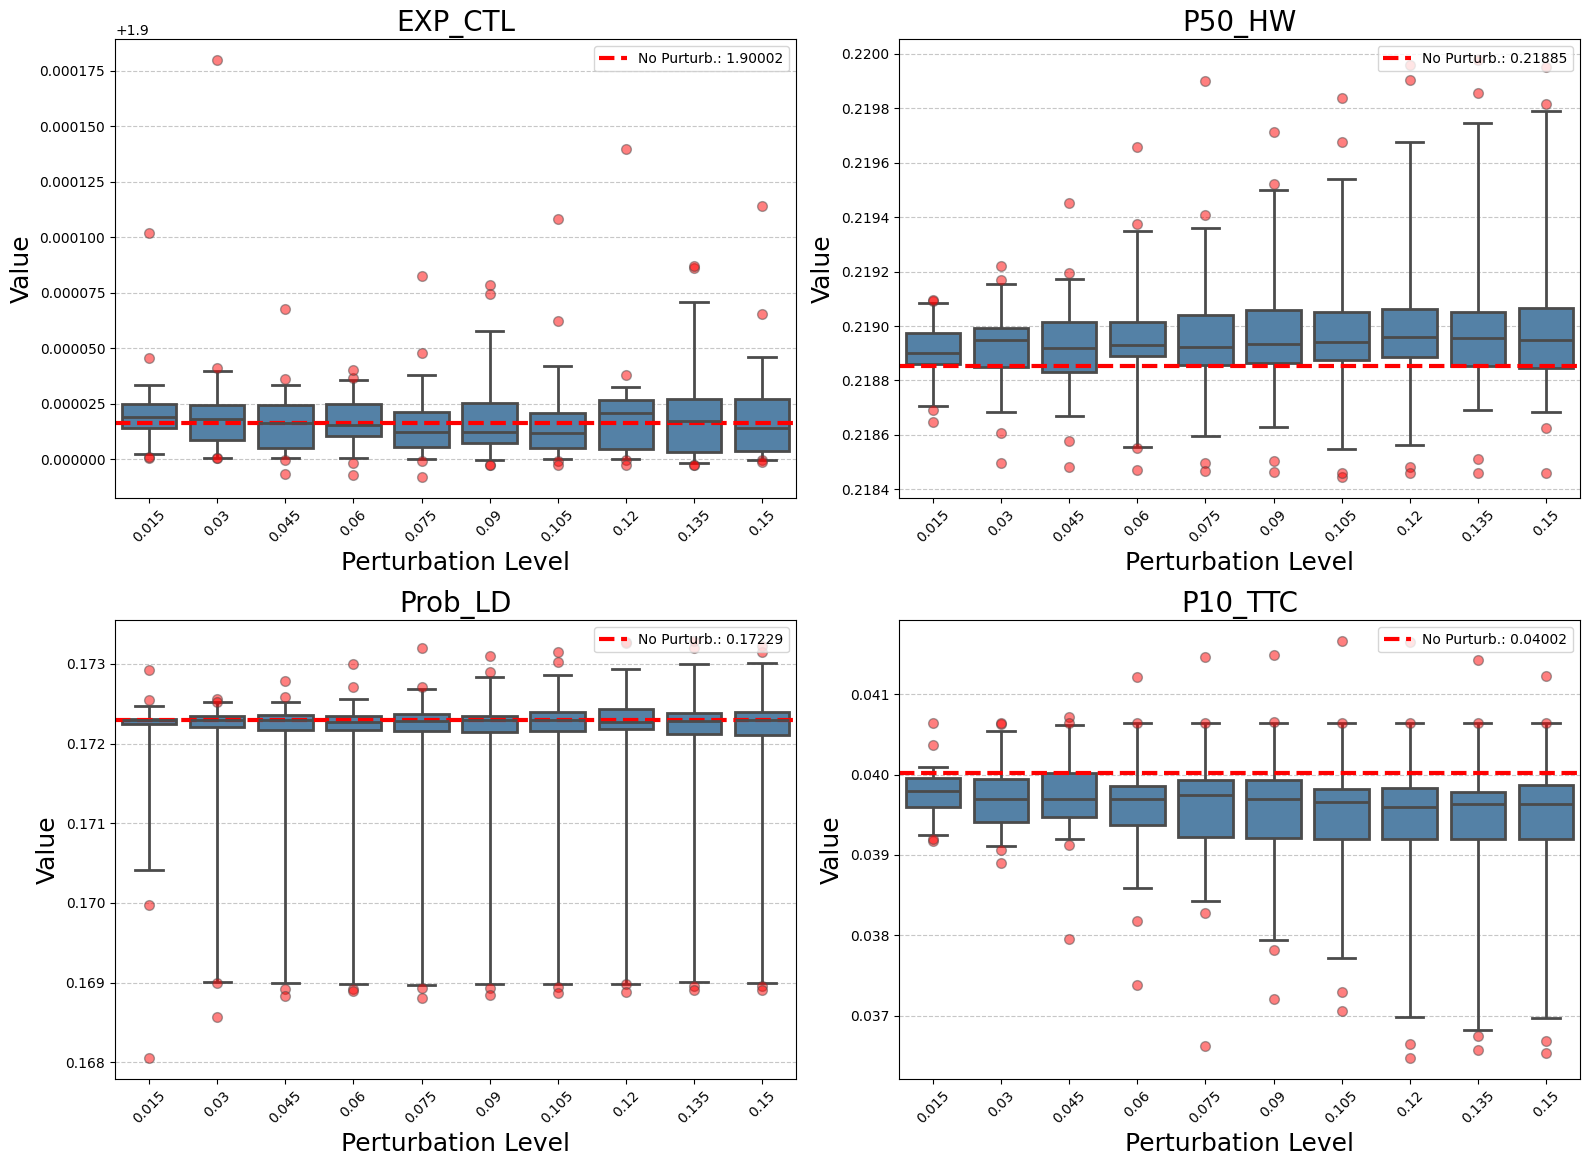

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metric_names = ["EXP_CTL", "P50_HW", "Prob_LD", "P10_TTC"]

# Assuming all_output_data and plot_factor_labels are defined

# --- 1. Define Baseline Values ---
BASELINE_VALUES = {
    'ctrl_cost': 1.900016325,
    'headway_cost': 0.218851459,
    'lane_dep_cost': 0.1722929549,
    'ttc_cost': 0.04001958255
}
# --- End Baseline Definition ---

# --- Setup for Plotting ---
num_factors = 10
plot_factor_labels = [0.015, 0.03, 0.045, 0.06, 0.075, 0.09, 0.105, 0.12, 0.135, 0.15]
cost_keys = list(all_output_data.keys()) 

# --- 2. Combined Data Preparation (Same as before) ---
master_data_list = []

for cost_key in cost_keys:
    all_values_flat = []
    all_factor_labels = []
    
    for i in range(num_factors):
        current_data = all_output_data[cost_key][i]
        all_values_flat.extend(current_data)
        label = plot_factor_labels[i]
        all_factor_labels.extend([label] * len(current_data))
        
    df_long_plot = pd.DataFrame({
        'Factor_Label': all_factor_labels,
        'Value': all_values_flat,
        'Metric': cost_key
    })
    master_data_list.append(df_long_plot)

df_master = pd.concat(master_data_list, ignore_index=True)
df_master['Factor_Label'] = df_master['Factor_Label'].astype(str)
# --- End Data Preparation ---


# --- 3. Generate the 2x2 Subplots with Baseline Line ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

#fig.suptitle('Box Plots of Cost Metrics by Scaling Factor Level (Baseline Indicated)', fontsize=18, y=1.02)

for i, cost_key in enumerate(cost_keys):
    # Determine the corresponding metric name for dictionary lookup
    df_subset = df_master[df_master['Metric'] == cost_key]
    ax = axes[i]
    
    # Generate the box plot 
    sns.boxplot(
        data=df_subset,
        x='Factor_Label', 
        y='Value', 
        color='steelblue',
        #legend=False,
        ax=ax,
        #palette="viridis",
        linewidth=2.0, 
        flierprops=dict(marker='o', markersize=7, markerfacecolor='red', alpha=0.5),
        whis=[5,95]
    )
    
    # --- ADD BASELINE LINE ---
    baseline_value = BASELINE_VALUES[cost_key]
    
    # Draw a horizontal line across the entire subplot at the baseline value
    ax.axhline(
        y=baseline_value, 
        color='red', 
        linestyle='--', 
        linewidth=3, 
        label=f'No Purturb.: {baseline_value:.5f}'
    )
    # --- END BASELINE LINE ---
    
    # Set titles and labels
    metric_name = metric_names[i]
    ax.set_title(f'{metric_name}', fontsize=20)
    ax.set_xlabel('Perturbation Level', fontsize=18)
    ax.set_ylabel('Value', fontsize=18)
    ax.tick_params(axis='x', rotation=45) 
    ax.legend(loc='upper right') # Show legend to include the baseline label
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.rcParams.update({'font.size': 16})
file_name = f'sens_analy_boxplots.pdf'
plt.savefig(file_name, bbox_inches='tight')
print(f"Plot saved successfully and cropped as: {file_name}")
plt.show()
plt.close(fig)